# Notebook for basic transfo in Python (matrix manipulation)

please visit : https://www.sfu.ca/~jtmulhol/py4math/linalg/ap-image-basics/


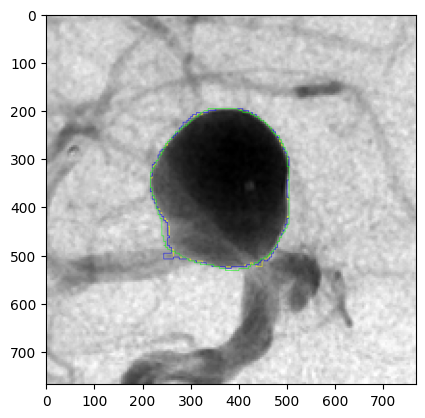

In [3]:
import matplotlib.pyplot as plt
import numpy as np
img = plt.imread("imgs/patient2.tif")
plt.imshow(img)

Text(0.5, 1.0, 'image in 3 colors')

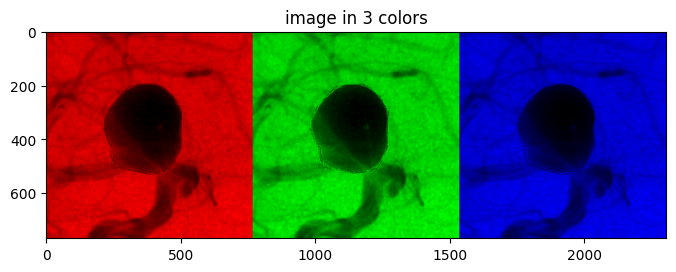

In [4]:
import numpy as np
img_R, img_G, img_B = img.copy(), img.copy(), img.copy()
img_R[:, :, (1, 2)] = 0  # zero out GB channels
img_G[:, :, (0, 2)] = 0  # zero out RB channels
img_B[:, :, (0, 1)] = 0  # zero out RG channels

img_rgb = np.concatenate((img_R,img_G,img_B), axis=1)
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("image in 3 colors")

(768, 768, 3)

## Rotating

performing rotation using cv2 using rotation matrix

<semantics><mrow><mi>R</mi><mo>=</mo><mrow><mo fence="true">[</mo><mtable rowspacing="0.16em" columnalign="center center" columnspacing="1em"><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mi>cos</mi><mo>⁡</mo><mi>θ</mi></mrow></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mo>−</mo><mi>sin</mi><mo>⁡</mo><mi>θ</mi></mrow></mstyle></mtd></mtr><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mi>sin</mi><mo>⁡</mo><mi>θ</mi></mrow></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mi>cos</mi><mo>⁡</mo><mi>θ</mi></mrow></mstyle></mtd></mtr></mtable><mo fence="true">]</mo></mrow></mrow><annotation encoding="application/x-tex">R =
\begin{bmatrix}
\cos\theta  -\sin\theta\\
\sin\theta  \cos\theta
\end{bmatrix}</annotation></semantics>

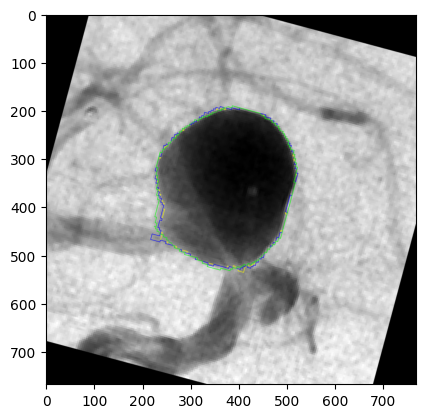

In [5]:
import cv2

h, w = img.shape[:2]  # height, width
ctr = (w // 2, h // 2)
ang = 15  # degrees
scl = 1.0

theta = np.deg2rad(ang)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

t = np.array([ctr[0], ctr[1]]) - R @ np.array([ctr[0], ctr[1]])
M = np.hstack((R, t.reshape(2, 1)))
rot = cv2.warpAffine(img, M, (w, h))

plt.imshow(rot)


## Translation
<semantics><mrow><mi>M</mi><mo>=</mo><mrow><mo fence="true">[</mo><mtable rowspacing="0.16em" columnalign="center center center" columnspacing="1em"><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>1</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><msub><mi>t</mi><mi>x</mi></msub></mstyle></mtd></mtr><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>1</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><msub><mi>t</mi><mi>y</mi></msub></mstyle></mtd></mtr></mtable><mo fence="true">]</mo></mrow></mrow><annotation encoding="application/x-tex">M =
\begin{bmatrix}
1  0  t_x\\
0  1  t_y
\end{bmatrix}</annotation></semantics>

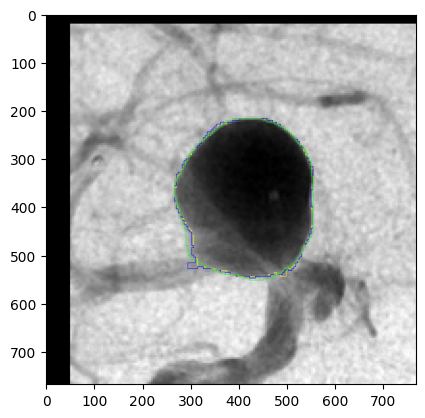

In [6]:
import cv2

h, w = img.shape[:2]  # height, width
ctr = (w // 2, h // 2)

tx = 50   # shift right
ty = 20   # shift down

T = np.array([
    [1, 0, tx],
    [0,  1, ty]
]).astype(np.float32)


trans = cv2.warpAffine(img, T, (img.shape[0], img.shape[1]))

plt.imshow(trans)

## flipping

**horizontal flipping**


<mrow><mo fence="true">[</mo><mtable rowspacing="0.16em" columnalign="center center center" columnspacing="1em"><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mo>−</mo><mn>1</mn></mrow></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mrow><mi>w</mi><mo>−</mo><mn>1</mn></mrow></mstyle></mtd></mtr><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>1</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd></mtr><mtr><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>0</mn></mstyle></mtd><mtd><mstyle scriptlevel="0" displaystyle="false"><mn>1</mn></mstyle></mtd></mtr></mtable><mo fence="true">]</mo></mrow><annotation encoding="application/x-tex">\begin{bmatrix}
-1 &amp; 0 &amp; w-1\\
0 &amp; 1 &amp; 0\\
0 &amp; 0 &amp; 1
\end{bmatrix}</annotation>

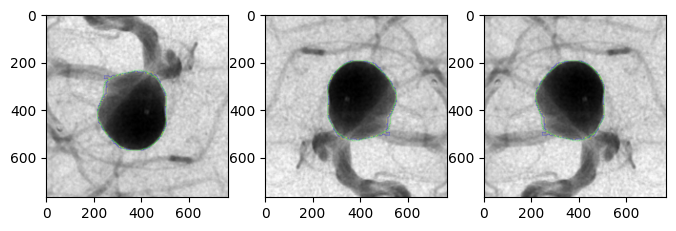

In [7]:



h, w = img.shape[:2]  # height, width
HF = np.array([[-1, 0, w-1],
             [0, 1, 0]]).astype(np.float32)


VF = np.array([[1,0,0],
               [0,-1,h-1]]).astype(np.float32)
h_flipped =  cv2.warpAffine(img, HF, (img.shape[1], img.shape[0]))

v_flipped = cv2.warpAffine(img, VF, (img.shape[1], img.shape[0]))

fig, ax = plt.subplots(ncols=3,  figsize=(8,5))

ax[0].imshow(v_flipped)
ax[1].imshow(h_flipped)
ax[2].imshow(img) 

## Shearing
along y axis :
[x y][[1 Shy]
        [0 1]]

along x axis:
[x y][[1 0]
        shx 1]]

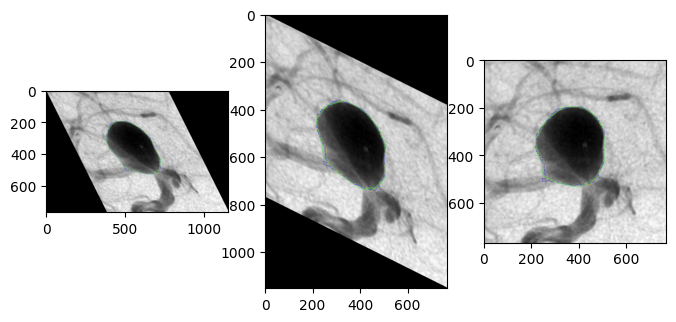

In [18]:
# shearing along y axis
shy = .5
Sy = np.float32([[1, shy, 0], [0, 1, 0]])

new_width = int(img.shape[1] + abs(shy) * img.shape[0])
shy_img = cv2.warpAffine(img, Sy, (new_width, img.shape[0]))


# shearing along x axis
shx = .5
Sx = np.float32([[1, 0, 0], [shx, 1, 0]])

new_height = int(img.shape[0] + abs(shx) * img.shape[1])
shx_img = cv2.warpAffine(img, Sx, (img.shape[0], new_height, ))

fig, ax = plt.subplots(ncols=3,  figsize=(8,5))

ax[0].imshow(shy_img)
ax[1].imshow(shx_img)
ax[2].imshow(img) 

##  Modifying colors

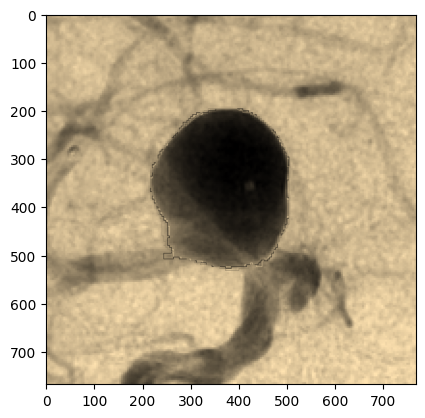

In [9]:
def apply_color_matrix(img, matrix):
    _img = img / 256
    _img = _img @ matrix.T

    _img /= _img.max()
    _img *= 255
    return _img.astype('uint8')


# ex applying sepia

sepia = np.array([[ 0.393, 0.769, 0.189],                   
    [ 0.349, 0.686, 0.168],
    [ 0.272, 0.534, 0.131]])


sepia_img = apply_color_matrix(img, sepia)
plt.imshow(sepia_img)


## Convolution with gaussian kernels


$g(x,y) = \frac{1}{2\pi\sigma^2} e^{\frac{-x^2-y^2}{2\sigma^2}}
= \left(\frac{1}{\sqrt{2\pi}\sigma} e^{\frac{-x^2}{2\sigma^2}}\right)\left(\frac{1}{\sqrt{2\pi}\sigma} e^{\frac{-y^2}{2\sigma^2}}\right)$


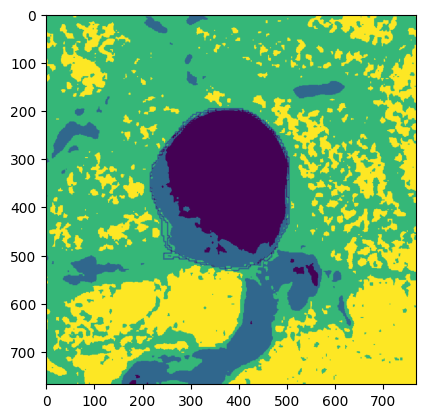

In [12]:
import numpy as np
from scipy.ndimage import convolve
def gaussian_kernel(kernel_size, sigma=1):
    size = int(kernel_size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g    



plt.imshow(convolve(img[:,:,0], gaussian_kernel(3, 10)))

## Basic transf for 3d images

From the tutorial:
https://scikit-image.org/docs/0.25.x/auto_examples/applications/plot_3d_image_processing.html

In [1]:

!pip install plotly
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

import plotly
import plotly.express as px
import skimage as ski

In [2]:
data = ski.util.img_as_float(ski.data.cells3d()[:, 1, :, :])  # grab just the nuclei

print(f'shape: {data.shape}')
print(f'dtype: {data.dtype}')
print(f'range: ({data.min()}, {data.max()})')

# Report spacing from microscope
original_spacing = np.array([0.2900000, 0.0650000, 0.0650000])

# Account for downsampling of slices by 4
rescaled_spacing = original_spacing * [1, 4, 4]

# Normalize spacing so that pixels are a distance of 1 apart
spacing = rescaled_spacing / rescaled_spacing[2]

print(f'microscope spacing: {original_spacing}\n')
print(f'rescaled spacing: {rescaled_spacing} (after downsampling)\n')
print(f'normalized spacing: {spacing}\n')

shape: (60, 256, 256)
dtype: float64
range: (0.0, 1.0)
microscope spacing: [0.29  0.065 0.065]

rescaled spacing: [0.29 0.26 0.26] (after downsampling)

normalized spacing: [1.11538462 1.         1.        ]



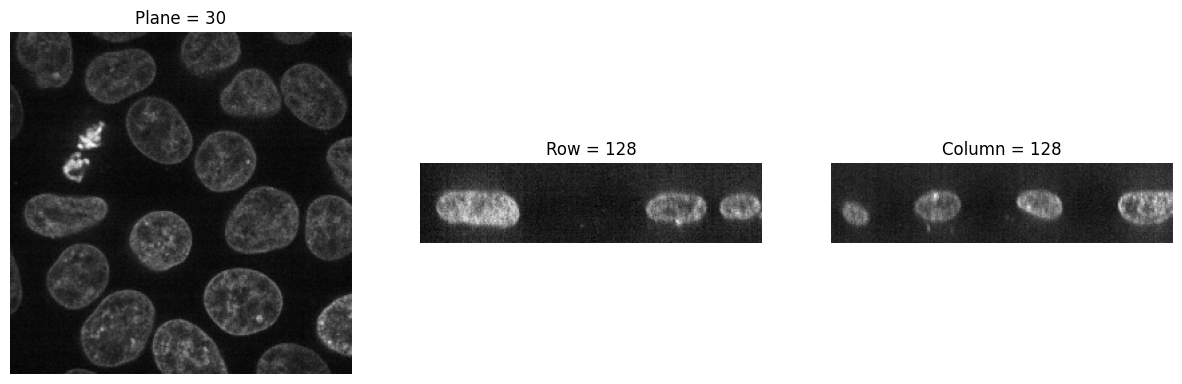

In [3]:
def show_plane(ax, plane, cmap="gray", title=None):
    ax.imshow(plane, cmap=cmap)
    ax.set_axis_off()

    if title:
        ax.set_title(title)


(n_plane, n_row, n_col) = data.shape
_, (a, b, c) = plt.subplots(ncols=3, figsize=(15, 5))

show_plane(a, data[n_plane // 2], title=f'Plane = {n_plane // 2}')
show_plane(b, data[:, n_row // 2, :], title=f'Row = {n_row // 2}')
show_plane(c, data[:, :, n_col // 2], title=f'Column = {n_col // 2}')

In [4]:
def slice_in_3D(ax, i):
    # From https://stackoverflow.com/questions/44881885/python-draw-3d-cube
    Z = np.array(
        [
            [0, 0, 0],
            [1, 0, 0],
            [1, 1, 0],
            [0, 1, 0],
            [0, 0, 1],
            [1, 0, 1],
            [1, 1, 1],
            [0, 1, 1],
        ]
    )

    Z = Z * data.shape
    r = [-1, 1]
    X, Y = np.meshgrid(r, r)

    # Plot vertices
    ax.scatter3D(Z[:, 0], Z[:, 1], Z[:, 2])

    # List sides' polygons of figure
    verts = [
        [Z[0], Z[1], Z[2], Z[3]],
        [Z[4], Z[5], Z[6], Z[7]],
        [Z[0], Z[1], Z[5], Z[4]],
        [Z[2], Z[3], Z[7], Z[6]],
        [Z[1], Z[2], Z[6], Z[5]],
        [Z[4], Z[7], Z[3], Z[0]],
        [Z[2], Z[3], Z[7], Z[6]],
    ]

    # Plot sides
    ax.add_collection3d(
        Poly3DCollection(
            verts, facecolors=(0, 1, 1, 0.25), linewidths=1, edgecolors="darkblue"
        )
    )

    verts = np.array([[[0, 0, 0], [0, 0, 1], [0, 1, 1], [0, 1, 0]]])
    verts = verts * (60, 256, 256)
    verts += [i, 0, 0]

    ax.add_collection3d(
        Poly3DCollection(verts, facecolors="magenta", linewidths=1, edgecolors="black")
    )

    ax.set_xlabel("plane")
    ax.set_xlim(0, 100)
    ax.set_ylabel("row")
    ax.set_zlabel("col")

    # Autoscale plot axes
    scaling = np.array([getattr(ax, f'get_{dim}lim')() for dim in "xyz"])
    ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]] * 3)


def explore_slices(data, cmap="gray"):
    from ipywidgets import interact

    N = len(data)

    @interact(plane=(0, N - 1))
    def display_slice(plane=34):
        fig, ax = plt.subplots(figsize=(20, 5))

        ax_3D = fig.add_subplot(133, projection="3d")

        show_plane(ax, data[plane], title=f'Plane {plane}', cmap=cmap)
        slice_in_3D(ax_3D, plane)

        plt.show()

    return display_slice


explore_slices(data)

interactive(children=(IntSlider(value=34, description='plane', max=59), Output()), _dom_classes=('widget-inter…

<function __main__.explore_slices.<locals>.display_slice(plane=34)>

In [6]:
data.shape

(60, 256, 256)

In [7]:
### Translation

In [9]:
import numpy
from scipy.ndimage import affine_transform
tx, ty, tz = 5, -2, 1

T = np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
])

# compute inverse mapping
Minv = np.linalg.inv(T)

A = Minv[:3, :3]
offset = Minv[:3, 3]

result = affine_transform(
    data,
    matrix=A,
    offset=offset,
    order=1,
    mode='constant',
    cval=0
)

In [10]:
result.shape

(60, 256, 256)

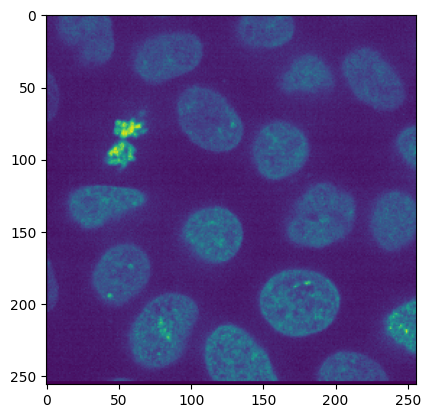

In [12]:
plt.imshow(result[30])


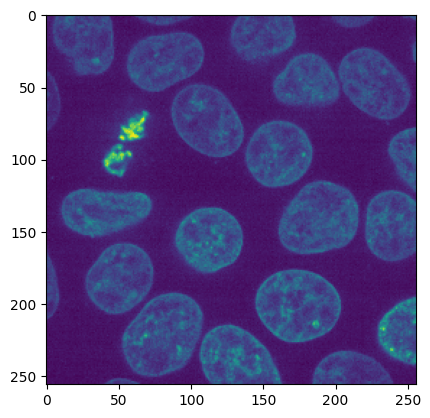

In [13]:
plt.imshow(data[30])

In [ ]:
## 3d image matrix rotation



In [18]:
# rotation about the z axis
theta = np.deg2rad(30)

Rz = np.eye(4)
Rz[:3,:3] = np.array([
    [1,              0,               0],
    [0,  np.cos(theta), -np.sin(theta)],
    [0,  np.sin(theta),  np.cos(theta)]
])


# here we do a rotation from the center of the iomage: it means we need tranlslation + rotation from the center + translation 
center = np.array([
    (60 - 1) / 2,
    (256 - 1) / 2,
    (256 - 1) / 2
])

T1 = np.eye(4)
T1[:3, 3] = -center

T2 = np.eye(4)
T2[:3, 3] = center

M = T2 @ Rz @ T1

result = affine_transform(
    data,
    matrix=M,
    offset=offset,
    order=1,
    mode='constant',
    cval=0
)

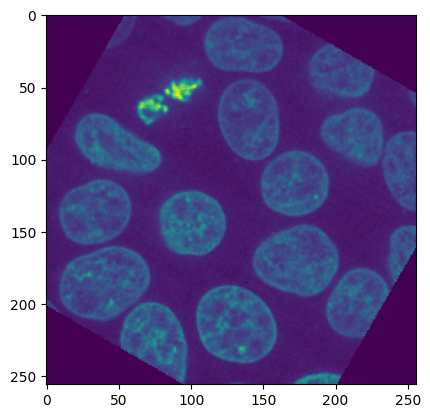

In [19]:
plt.imshow(result[30])